# Step 1 Data Exploration

Visualize the joined dataset for any city. Set `CITY` in the next cell.

- **Delft** loads `delft/bag_3dbag_ep_joined.parquet` (3-source: BAG + 3D BAG + EP-Online).
- **Amsterdam / Utrecht / Rotterdam** load `<city>/bag_ep_joined.parquet` (2-source: BAG + EP-Online; no `b3_*` columns).

Cells that use 3D BAG fields gracefully skip those fields when they are absent.

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# Parameter — change to explore a different city
CITY = "amsterdam"   # one of: delft, amsterdam, utrecht, rotterdam

CITY_DIR = Path("../data/processed") / CITY
CANDIDATES = [
    CITY_DIR / "bag_3dbag_ep_joined.parquet",   # 3-source (Delft)
    CITY_DIR / "bag_ep_joined.parquet",          # 2-source (other cities)
]
PARQUET = next((p for p in CANDIDATES if p.exists()), None)
if PARQUET is None:
    raise FileNotFoundError(f"No joined parquet found for city '{CITY}' in {CITY_DIR}")

gdf = gpd.read_parquet(PARQUET)
HAS_3DBAG = any(c.startswith("b3_") for c in gdf.columns)

print(f"City:    {CITY}")
print(f"Source:  {PARQUET.name}  ({'3-source' if HAS_3DBAG else '2-source'})")
print(f"Shape:   {gdf.shape}")
print(f"CRS:     {gdf.crs.to_string() if gdf.crs else 'unknown'}")

PREVIEW_COLS = ["pand_id", "bouwjaar", "Energieklasse"]
PREVIEW_COLS += [c for c in ("b3_dak_type", "b3_opp_grond") if c in gdf.columns]
gdf[PREVIEW_COLS].head(10)

City:    amsterdam
Source:  bag_ep_joined.parquet  (2-source)
Shape:   (63785, 21)
CRS:     EPSG:28992


,pand_id,bouwjaar,Energieklasse
0,0394100000212792,1901,C
1,0394100000211294,1940,C
2,0394100000210342,1901,G
3,0394100000214881,1925,E
4,0394100000215583,1925,B
5,0394100000217127,2009,B
6,0394100000206975,1940,E
7,0394100000206982,1952,C
8,0394100000208560,1932,D
9,0394100000211204,1935,F


In [ ]:
print(f"Total columns: {len(gdf.columns)}\n")
for i, col in enumerate(gdf.columns, 1):
    print(f"{i:3d}. {col}")

Total columns: 21

  1. id
  2. identificatie
  3. rdf_seealso
  4. bouwjaar
  5. status
  6. gebruiksdoel
  7. oppervlakte_min
  8. oppervlakte_max
  9. aantal_verblijfsobjecten
 10. geometry
 11. pand_id
 12. Registratiedatum
 13. Status
 14. Gebouwklasse
 15. Gebouwtype
 16. Postcode
 17. BAGPandIDs
 18. Bouwjaar
 19. Energieklasse
 20. EnergieIndex
 21. build_period


## Interactive Map — Energy Labels

In [ ]:
tooltip_cols = ["pand_id", "bouwjaar", "Energieklasse"]
if "b3_dak_type" in gdf.columns:
    tooltip_cols.append("b3_dak_type")

gdf.explore(
    column="Energieklasse",
    tooltip=tooltip_cols,
    popup=True,
    cmap="RdYlGn",
    style_kwds={"weight": 0.5, "fillOpacity": 0.7},
    tiles="CartoDB positron",
)

## Energy Label Distribution

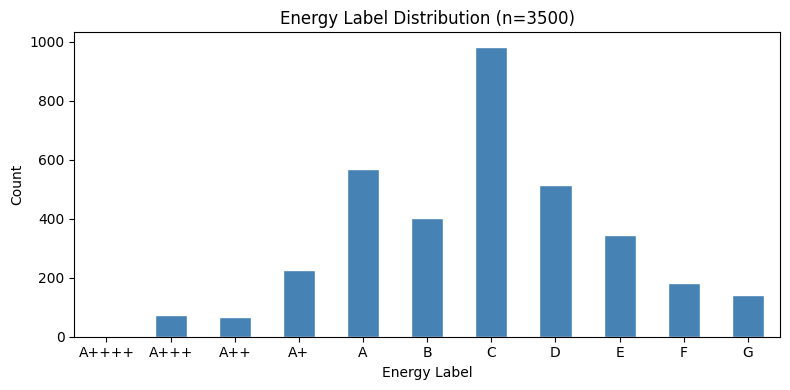

In [47]:
label_order = ["A++++", "A+++", "A++", "A+", "A", "B", "C", "D", "E", "F", "G"]
counts = gdf["Energieklasse"].value_counts().reindex(label_order).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Energy Label")
ax.set_ylabel("Count")
ax.set_title(f"Energy Label Distribution (n={len(gdf)})")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Construction Year & Build Period

DEBUG period_counts:
build_period
1800-1849      70
1850-1899     412
1900-1949    1582
1950-1999    1063
>2000         373
Name: count, dtype: int64


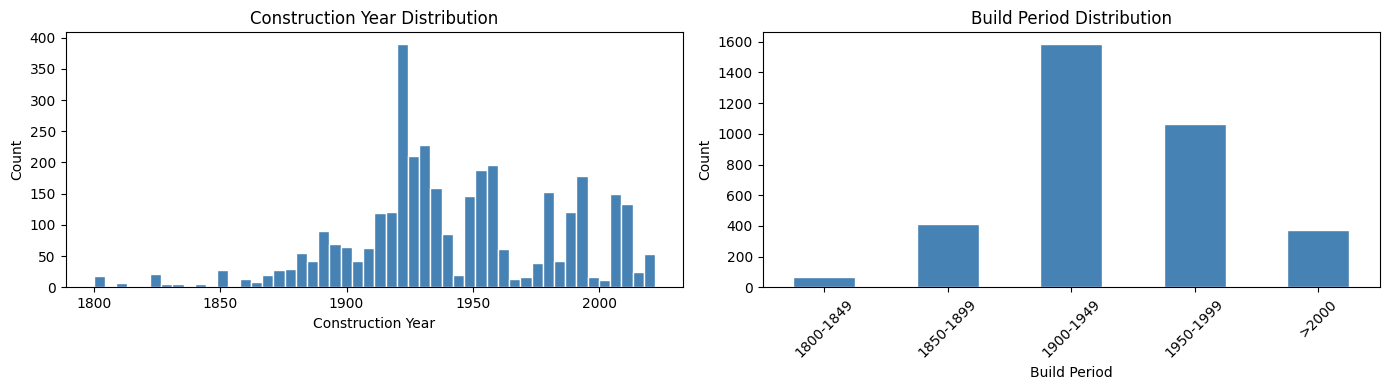

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of construction year
axes[0].hist(gdf["bouwjaar"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Construction Year")
axes[0].set_ylabel("Count")
axes[0].set_title("Construction Year Distribution")

# Build period bar chart
period_order = ["1800-1849", "1850-1899", "1900-1949", "1950-1999", ">2000"]
period_counts = gdf["build_period"].value_counts().reindex(period_order)
print("DEBUG period_counts:")
print(period_counts)
period_counts.plot.bar(ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_xlabel("Build Period")
axes[1].set_ylabel("Count")
axes[1].set_title("Build Period Distribution")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()